In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [11]:
import pandas as pd

df = pd.read_excel("/content/sample_data/Data_Analyst_Internship_Restaurant_Dataset (1).xlsx")

print(df.head())

                     Restaurant Name       City                 Cuisines  \
0  Paradise Biryani - Special Branch    Chennai                  Chinese   
1             New Cafe - City Branch      Delhi                     Cafe   
2                       Masala House  Bangalore     Biryani, Continental   
3        Cream Stone - Banjara Hills  Hyderabad  Fast Food, South Indian   
4                     Street Food Co    Chennai    Mexican, South Indian   

   Rating  Votes  Price Range (1-4) Online Delivery  
0     4.6  12500                  2             Yes  
1     2.6     12                  3              No  
2     4.4    805                  1              No  
3     4.7   4048                  3              No  
4     4.1    740                  2             Yes  


In [12]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (120, 7)

Column Names:
['Restaurant Name', 'City', 'Cuisines', 'Rating', 'Votes', 'Price Range (1-4)', 'Online Delivery']

Missing Values:
Restaurant Name      0
City                 0
Cuisines             0
Rating               0
Votes                0
Price Range (1-4)    0
Online Delivery      0
dtype: int64


In [13]:


df["Cuisine Combination"] = df["Cuisines"].apply(
    lambda x: ", ".join(sorted([c.strip() for c in x.split(",")]))
)

# Count the cuisine combinations
combination_counts = df["Cuisine Combination"].value_counts()

print("Top 10 Most Common Cuisine Combinations:")
print(combination_counts.head(10))

Top 10 Most Common Cuisine Combinations:
Cuisine Combination
Chinese                 7
North Indian            5
Thai                    5
Andhra                  5
Fast Food               5
Cafe                    4
Italian                 3
Biryani, Continental    3
Seafood                 3
Bakery                  3
Name: count, dtype: int64


In [14]:
# Select only restaurants having 2 or more cuisines

df["Cuisine Count"] = df["Cuisines"].apply(
    lambda x: len(x.split(","))
)

multi_cuisine = df[df["Cuisine Count"] >= 2]

# Count the cuisine combinations
combination_counts = multi_cuisine["Cuisine Combination"].value_counts()

print("Top 10 Cuisine Combinations:")
print(combination_counts.head(10))

Top 10 Cuisine Combinations:
Cuisine Combination
Biryani, Continental     3
Andhra, South Indian     3
Cafe, South Indian       2
Andhra, Chinese          2
Seafood, Thai            2
Mexican, South Indian    2
Bakery, Cafe             2
Biryani, South Indian    2
Andhra, Bakery           2
Continental, Italian     2
Name: count, dtype: int64


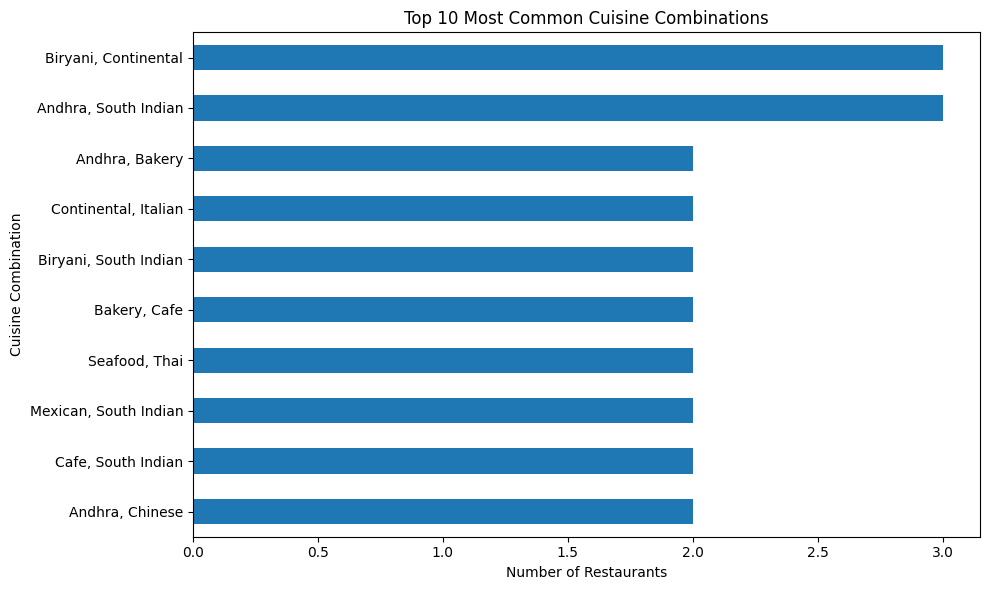

In [15]:
import matplotlib.pyplot as plt

# Get the top 10 cuisine combinations
top_10 = combination_counts.head(10)

# Create the bar chart
plt.figure(figsize=(10, 6))

top_10.sort_values().plot(kind="barh")

plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Combination")

plt.tight_layout()
plt.show()

In [16]:
# Calculate restaurant count and average rating
rating_analysis = df[df["Cuisine Count"] >= 2].groupby(
    "Cuisine Combination"
).agg(
    Restaurant_Count=("Restaurant Name", "count"),
    Average_Rating=("Rating", "mean")
).sort_values("Average_Rating", ascending=False)

print("Cuisine Combinations with Average Ratings:")
print(rating_analysis.head(10))

Cuisine Combinations with Average Ratings:
                             Restaurant_Count  Average_Rating
Cuisine Combination                                          
Andhra, Cafe                                1            4.90
Cafe, Fast Food                             1            4.80
Fast Food, South Indian                     1            4.70
Chinese, Seafood                            1            4.60
Chinese, Italian, Mexican                   1            4.60
Cafe, Italian, South Indian                 1            4.50
Bakery, Mexican, Mughlai                    1            4.20
Seafood, Thai                               2            4.15
Mexican, South Indian                       2            4.10
Continental, North Indian                   1            4.10


In [17]:
# Calculate restaurant count and average rating
rating_analysis = df[df["Cuisine Count"] >= 2].groupby(
    "Cuisine Combination"
).agg(
    Restaurant_Count=("Restaurant Name", "count"),
    Average_Rating=("Rating", "mean")
).sort_values("Average_Rating", ascending=False)

print("Cuisine Combinations with Average Ratings:")
print(rating_analysis.head(10))

Cuisine Combinations with Average Ratings:
                             Restaurant_Count  Average_Rating
Cuisine Combination                                          
Andhra, Cafe                                1            4.90
Cafe, Fast Food                             1            4.80
Fast Food, South Indian                     1            4.70
Chinese, Seafood                            1            4.60
Chinese, Italian, Mexican                   1            4.60
Cafe, Italian, South Indian                 1            4.50
Bakery, Mexican, Mughlai                    1            4.20
Seafood, Thai                               2            4.15
Mexican, South Indian                       2            4.10
Continental, North Indian                   1            4.10


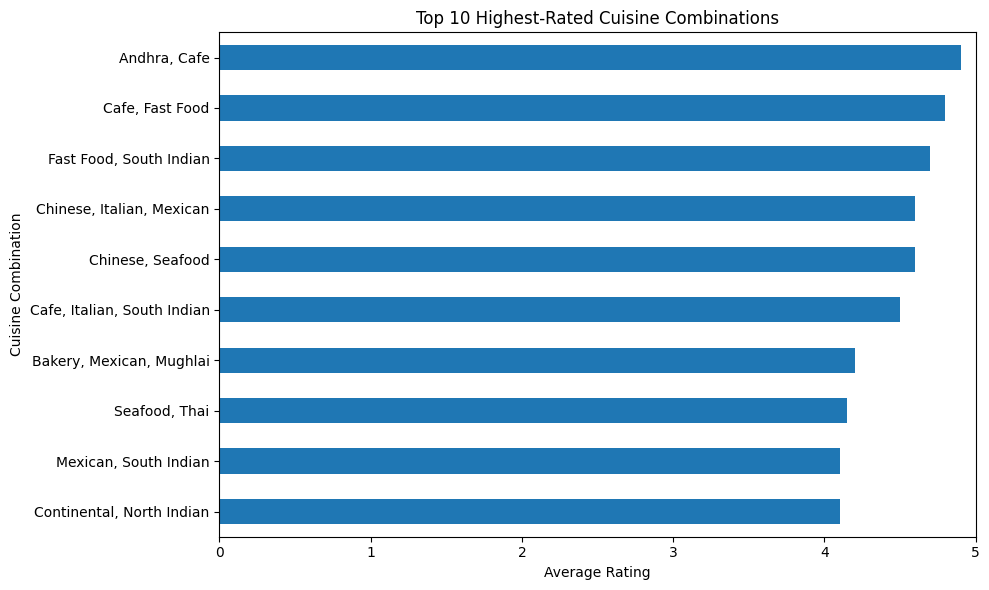

In [19]:
# Plot the top-rated cuisine combinations

top_rated = rating_analysis.head(10)

plt.figure(figsize=(10, 6))

top_rated["Average_Rating"].sort_values().plot(kind="barh")

plt.title("Top 10 Highest-Rated Cuisine Combinations")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Combination")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [21]:
# Combine frequency and rating information

final_analysis = rating_analysis.copy()

final_analysis["Number_of_Restaurants"] = final_analysis["Restaurant_Count"]

final_analysis = final_analysis[
    ["Number_of_Restaurants", "Average_Rating"]
]

final_analysis = final_analysis.sort_values(
    "Number_of_Restaurants",
    ascending=False
)

print("Cuisine Combination Analysis:")
print(final_analysis.head(10))

Cuisine Combination Analysis:
                       Number_of_Restaurants  Average_Rating
Cuisine Combination                                         
Biryani, Continental                       3            4.00
Andhra, South Indian                       3            3.20
Continental, Italian                       2            3.95
Andhra, Bakery                             2            3.80
Mexican, South Indian                      2            4.10
Andhra, Chinese                            2            3.10
Cafe, South Indian                         2            3.60
Bakery, Cafe                               2            3.20
Biryani, South Indian                      2            3.65
Seafood, Thai                              2            4.15


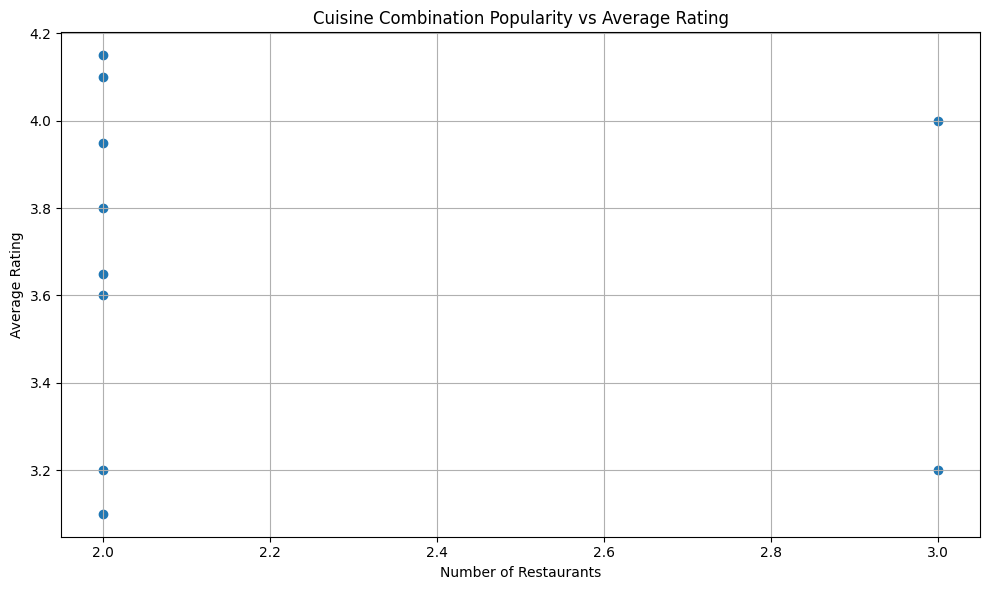

In [22]:
# Compare number of restaurants with average rating

top_combinations_analysis = final_analysis.head(10)

plt.figure(figsize=(10, 6))

plt.scatter(
    top_combinations_analysis["Number_of_Restaurants"],
    top_combinations_analysis["Average_Rating"]
)

plt.title("Cuisine Combination Popularity vs Average Rating")
plt.xlabel("Number of Restaurants")
plt.ylabel("Average Rating")

plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
best = rating_analysis.sort_values(
    "Average_Rating",
    ascending=False
).iloc[0]

print("Highest-Rated Cuisine Combination:")
print("Cuisine Combination:", rating_analysis.sort_values(
    "Average_Rating",
    ascending=False
).index[0])
print("Number of Restaurants:", int(best["Restaurant_Count"]))
print("Average Rating:", round(best["Average_Rating"], 2))

Highest-Rated Cuisine Combination:
Cuisine Combination: Andhra, Cafe
Number of Restaurants: 1
Average Rating: 4.9
